In [7]:
from pathlib import Path

from amoc_analysis import data, plotting
import matplotlib.pyplot as plt

In [3]:
ds = data.load_sample_dataset() 

Summary for array 'rapid':
Total datasets loaded: 1

Dataset 1:
  Source file: moc_transports.nc
  Time coverage: 2004-04-02 to 2023-02-11
  Dimensions:
    - TIME: 13779
  Variables:
    - t_therm10: shape (13779,)
    - t_aiw10: shape (13779,)
    - t_ud10: shape (13779,)
    - t_ld10: shape (13779,)
    - t_bw10: shape (13779,)
    - t_gs10: shape (13779,)
    - t_ek10: shape (13779,)
    - t_umo10: shape (13779,)
    - moc_mar_hc10: shape (13779,)



In [29]:
ds_mean=ds.mean()
ds_std=ds.std()

In [36]:
ds_std.t_ud10.values

array(2.52837504)

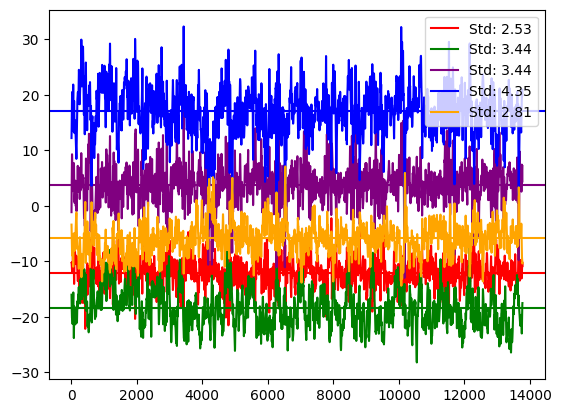

In [38]:
fig,ax=plt.subplots()

data=["t_ud10","t_umo10","t_ek10","moc_mar_hc10","t_ld10"]
colors=["red","green","purple","blue","orange"]

for i,d in enumerate(data):
    ax.plot(ds[d],c=colors[i])
    ax.axhline(ds_mean[d],c=colors[i],label=f"Std: {ds_std[d].values:.2f}")
ax.legend()


In [46]:
#ds_sub=ds.isel(TIME=slice(None,None,2))
ds_sub=ds.sel(TIME=ds.TIME.dt.hour==0)
ds_sub_mean=ds_sub.mean()
ds_sub_std=ds_sub.std()

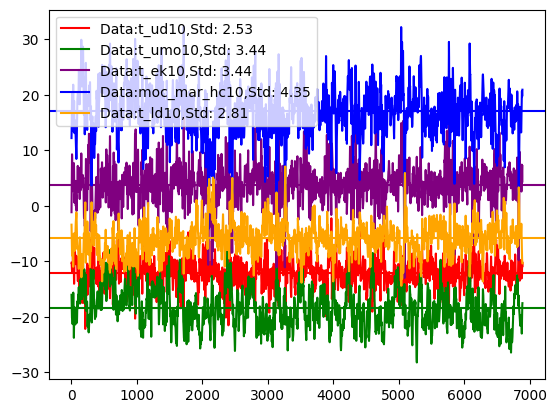

In [48]:
fig,ax=plt.subplots()

data=["t_ud10","t_umo10","t_ek10","moc_mar_hc10","t_ld10"]
colors=["red","green","purple","blue","orange"]

for i,d in enumerate(data):
    ax.plot(ds_sub[d],c=colors[i])
    ax.axhline(ds_sub_mean[d],c=colors[i],label=f"Data:{d},Std: {ds_sub_std[d].values:.2f}")
ax.legend()